# Classificação do BrainLat com os modelos treinados no ds004504

Fica na raiz do projeto, ao lado de `preprocessingData.ipynb` e `models_training.ipynb`.

1. Monta a coorte (AD e CN) a partir de `brainlat_eeg/` e dos CSVs de cognição.
2. Confere a adaptação de canais num sujeito de cada sítio (AR e CL).
3. Converte cada registro para o espaço do treino: 19 canais, referência ~orelhas, 500 Hz.
4. Roda o mesmo pré-processamento e as mesmas features do `preprocessingData`.
5. Treina e salva os modelos finais (se ainda não existirem) e classifica.

In [1]:
%pip install mne pymatreader mne-icalabel meegkit antropy tensorpac scikit-learn xgboost joblib matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 0 - caminhos

In [4]:
import sys, importlib, json
from pathlib import Path
import numpy as np
import pandas as pd
import joblib
import mne
import matplotlib.pyplot as plt

# Raiz do projeto = pasta que contém brainlat_eeg/ (sobe a partir da pasta atual)
PROJECT_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "brainlat_eeg").is_dir()), None)
assert PROJECT_ROOT is not None, f"não achei a pasta brainlat_eeg/ a partir de {Path.cwd()}"
sys.path.insert(0, str(PROJECT_ROOT))
import channel_adaptation, ds004504_features, brainlat_transfer, train_final_models
for m in (channel_adaptation, ds004504_features, brainlat_transfer, train_final_models):
    importlib.reload(m)

BRAINLAT_ROOT = PROJECT_ROOT / "brainlat_eeg"

# Procura os CSVs de rótulos em qualquer lugar do projeto (aceita nomes como
# "Cognition_AD_EEG_data (1).csv"). Se preferir, escreva os caminhos à mão:
# LABEL_CSVS = [Path(".../Cognition_AD_EEG_data.csv"), Path(".../Cognition_HC_EEG_data.csv")]
LABEL_CSVS = []
for stem in ("Cognition_AD_EEG_data", "Cognition_HC_EEG_data"):
    hits = sorted(PROJECT_ROOT.rglob(f"{stem}*.csv"), key=lambda p: (len(p.parts), str(p)))
    if not hits:
        raise FileNotFoundError(
            f"{stem}.csv não foi encontrado em nenhuma subpasta de {PROJECT_ROOT}. "
            "Copie os dois CSVs de cognição para essa pasta (ou qualquer subpasta dela).")
    if len(hits) > 1:
        print(f"{stem}: {len(hits)} cópias, usando a mais próxima da raiz:",
              [str(h.relative_to(PROJECT_ROOT)) for h in hits])
    LABEL_CSVS.append(hits[0])

TRAIN_FEATURES = PROJECT_ROOT / "eeg_features_baseline_data.csv"
MODEL_BUNDLE   = PROJECT_ROOT / "models" / "ds004504_models.joblib"
CACHE_DIR      = PROJECT_ROOT / "brainlat_features"        # um CSV + um JSON por sujeito
OUT_DIR        = PROJECT_ROOT / "resultados_brainlat"
OUT_DIR.mkdir(exist_ok=True)

TRAINING_SET_EXAMPLE = PROJECT_ROOT / "88 subjects" / "sub-001" / "eeg" / "sub-001_task-eyesclosed_eeg.set"
ORDER = channel_adaptation.training_channel_order(TRAINING_SET_EXAMPLE)

print("mne         :", mne.__version__)
print("projeto     :", PROJECT_ROOT)
print("rótulos     :", [str(p.relative_to(PROJECT_ROOT)) for p in LABEL_CSVS])
print("features    :", TRAIN_FEATURES.name, "OK" if TRAIN_FEATURES.exists() else "AUSENTE")
print("ordem treino:", ORDER)

mne         : 1.11.0
projeto     : c:\Universidade\NeuroComp\Memoria\ccnec
rótulos     : ['brainlat_eeg\\1_AD\\Cognition_AD_EEG_data.csv', 'brainlat_eeg\\5_HC\\Cognition_HC_EEG_data.csv']
features    : eeg_features_baseline_data.csv OK
ordem treino: ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T3', 'T4', 'T5', 'T6', 'Fz', 'Cz', 'Pz']


## 1 - coorte

Para cada linha dos CSVs, procura `brainlat_eeg/*/<sítio>/<id>` e o arquivo EEG dentro da
pasta. Também confere se a pasta de grupo (`1_AD`, `5_HC`) bate com o diagnóstico do CSV.

In [5]:
cohort = brainlat_transfer.build_cohort(BRAINLAT_ROOT, LABEL_CSVS, positive=("AD",), negative=("CN",))
print(cohort.groupby(["diagnosis", "site", "status"]).size().to_string())

problems = cohort[cohort["status"] != "ok"]
if len(problems):
    print("\nexcluídos:")
    print(problems[["sid", "diagnosis", "site", "status"]].to_string(index=False))
multi = cohort[cohort["n_eeg_files"] > 1]
if len(multi):
    print(f"\n{len(multi)} sujeitos com mais de um arquivo EEG; arquivo escolhido:")
    for r in multi.itertuples():
        print(f"  {r.sid}: {Path(r.eeg_file).name}  (de {r.n_eeg_files})")
print("\npastas sem rótulo nos CSVs:", cohort.attrs["unlabeled_on_disk"] or "nenhuma")

ok = cohort[cohort["status"] == "ok"].copy()
paths  = dict(zip(ok["sid"], ok["eeg_file"]))
labels = pd.Series(ok["y"].values, index=ok["sid"], name="y")
sites  = pd.Series(ok["site"].values, index=ok["sid"], name="site")
print(f"\ncoorte final: {len(ok)} ({labels.sum()} AD, {(labels == 0).sum()} CN)")

diagnosis  site  status
AD         AR    ok        16
           CL    ok        19
CN         AR    ok        19
           CL    ok        27

pastas sem rótulo nos CSVs: nenhuma

coorte final: 81 (35 AD, 46 CN)


## 2 - estado dos arquivos e adaptação de canais: um sujeito de cada sítio

Para cada sítio, confere primeiro o **estado do arquivo**:
- canais fora do escalpo (ECG, EXG): o nome `rs-HEP` sugere que há ECG;
- filtros já aplicados: o treino usa 0,5-45 Hz, e um passa-baixa abaixo de 45 Hz afeta a banda gama;
- referência média, trechos removidos (`boundary`) e amplitude.

Depois, a **adaptação**:
- de onde veio a geometria: `file`, `file_unverified` ou `template`;
- a tabela de correspondência e os eletrodos de referência;
- a figura: Fp1/Fp2 junto ao nariz, O1/O2 atrás, ímpares à esquerda, pares à direita.

AR | sub-30001 | s6_sub-30001_rs-HEP_eeg.set
ESTADO DO ARQUIVO
  canais: 128 {'eeg': 128} | escalpo: 128 | fora do escalpo: nenhum
  512 Hz, 312 s (5.2 min), posições válidas: 128
  filtros no cabeçalho: passa-alta 0.0 Hz, passa-baixa 256.0 Hz
  referência média? sim (razão 0.0) | amplitude mediana 6.96 µV | planos: 0 | ruins no cabeçalho: nenhum
  anotações: nenhuma
  primeiros nomes: ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10']
  últimos nomes  : ['D25', 'D26', 'D27', 'D28', 'D29', 'D30', 'D31', 'D32']
ADAPTAÇÃO
  geometria: file
   - divergência mediana arquivo x biosemi128: 0.4 graus em 128 eletrodos (limite 20.0)
   - deslocamento mediano 3.7 graus (limite 12.0)
training_name nominal source  angle_deg  approx_mm  nearest_was_free
          Fp1     Fp1    C29       1.68        2.8              True
          Fp2     Fp2    C16       2.32        3.8              True
           F3      F3    C32       5.73        9.5              True
           F4      F4    C10   

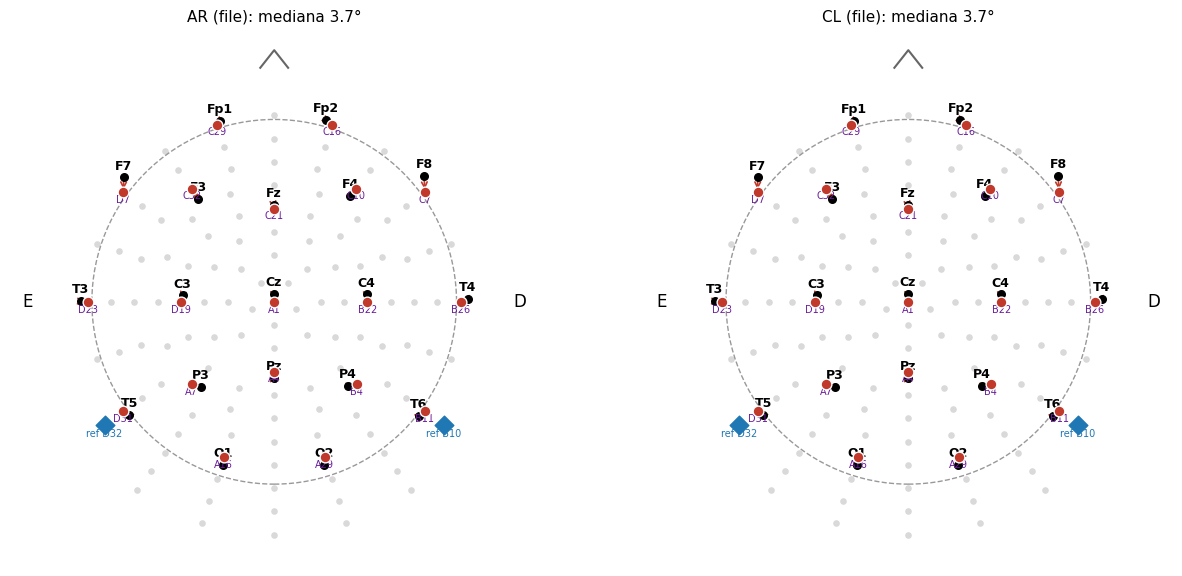

In [6]:
first_per_site = ok.groupby("site").head(1)
fig, axes = plt.subplots(1, len(first_per_site), figsize=(7.5 * len(first_per_site), 7.5))
axes = np.atleast_1d(axes)
recording_info = {}

for ax, r in zip(axes, first_per_site.itertuples()):
    print("=" * 78)
    print(f"{r.site} | {r.sid} | {Path(r.eeg_file).name}")
    try:
        raw = brainlat_transfer.read_raw_any(r.eeg_file)
    except brainlat_transfer.EpochedFileError as exc:
        print("  ", exc)
        ax.axis("off")
        continue

    print("ESTADO DO ARQUIVO")
    recording_info[r.site] = brainlat_transfer.describe_recording(raw)
    print(f"  primeiros nomes: {raw.ch_names[:10]}")
    print(f"  últimos nomes  : {raw.ch_names[-8:]}")

    print("ADAPTAÇÃO")
    pos, mp, src, notes = channel_adaptation.resolve_geometry(raw, "auto", ORDER)
    refs = channel_adaptation.nearest_channels(pos, exclude=set(mp["source"]))
    print(f"  geometria: {src}")
    for n in notes:
        print("   -", n)
    print(mp.to_string(index=False))
    print("  referência (proxies de mastoide):")
    print(refs.to_string(index=False))
    channel_adaptation.plot_mapping(pos, mp, refs["source"].tolist(),
                               title=f"{r.site} ({src}): mediana {mp['angle_deg'].median():.1f}°", ax=ax)

fig.savefig(OUT_DIR / "adaptacao_canais_por_sitio.png", dpi=150, bbox_inches="tight")
plt.show()

Parâmetros da adaptação. A referência padrão aproxima a referência nas orelhas do treino.
Se a conferência acima mostrar canais externos nas mastoides (EXG), troque para
`reference="explicit"` com esses canais.

In [7]:
ADAPTER_KWARGS = dict(
    mapping_source="auto",        # "auto" | "file" | "template"
    reference="mastoid_approx",   # "mastoid_approx" | "explicit" | "average"
    ref_channels=None,            # ex.: ["EXG1", "EXG2"] com reference="explicit"
    order=ORDER,
    max_duration_s=None,          # o treino usou o registro inteiro
)

## 3 - um sujeito do início ao fim

In [8]:
sid0 = first_per_site.iloc[0]["sid"]
raw = brainlat_transfer.read_raw_any(paths[sid0])
raw19, prov = channel_adaptation.adapt_to_training_space(raw, verbose=True, **ADAPTER_KWARGS)
assert raw19.ch_names == ORDER and raw19.info["sfreq"] == 500.0

raw_clean, rep = ds004504_features.clean_like_training(raw19)
print(f"ICA: {rep['n_ica_components']} componentes, excluídos {rep['ic_excluded']}")
print("ICLabel:", rep["ic_labels"])

short = raw_clean.copy().crop(tmax=12.0)
pd.DataFrame(ds004504_features.extract_epoch_features(short, sid0)).drop(
    columns=["Subject_ID", "Epoch_ID"]).T

  geometria=file (128 pos.), desloc. mediano 3.7 graus, ref=['D32', 'B10'], interpolados=nenhum, 512->500 Hz, 312 s


c:\Universidade\NeuroComp\Memoria\ccnec\ds004504_features.py:81: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  ic_labels = label_components(raw, ica, method="iclabel")


ICA: 19 componentes, excluídos [11, 13, 15, 16]
ICLabel: ['brain', 'brain', 'brain', 'brain', 'brain', 'brain', 'brain', 'brain', 'brain', 'brain', 'brain', 'eye blink', 'brain', 'muscle artifact', 'brain', 'muscle artifact', 'eye blink', 'brain', 'brain']


,0,1,2,3,4
Delta_Mean_Freq,1.822545,1.488421,2.068327,2.443480,2.645098
Theta_Mean_Freq,6.532126,6.779990,6.439452,6.142880,6.157596
Alpha_Mean_Freq,9.598755,9.500285,9.711052,9.716374,9.596493
Beta_Mean_Freq,18.609018,18.489029,17.204784,17.330721,17.463561
Gamma_Mean_Freq,32.684394,32.514794,32.224570,32.170387,32.072146
Delta_LZC,0.068392,0.064929,0.068969,0.078203,0.084841
Theta_LZC,0.157561,0.163332,0.159292,0.157850,0.163044
Alpha_LZC,0.191901,0.192478,0.202867,0.198538,0.204021
Beta_LZC,0.313391,0.294633,0.303002,0.296653,0.303291
Gamma_LZC,0.386977,0.386688,0.380628,0.387842,0.386977


## 4 - todos os sujeitos (com cache)

Cada sujeito gera `brainlat_features/<id>_epochs.csv` e `<id>_provenance.json`. Ao rodar de
novo, só quem falta é processado; `overwrite=True` refaz tudo.

In [10]:
epochs_df, failures = brainlat_transfer.run(paths, CACHE_DIR, adapter_kwargs=ADAPTER_KWARGS)
print(f"\n{epochs_df['Subject_ID'].nunique()} sujeitos, {len(epochs_df)} épocas")
for k, v in failures.items():
    print("FALHA", k, "->", v)

[1/81] sub-30001
  geometria=file (128 pos.), desloc. mediano 3.7 graus, ref=['D32', 'B10'], interpolados=nenhum, 512->500 Hz, 312 s


c:\Universidade\NeuroComp\Memoria\ccnec\ds004504_features.py:81: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  ic_labels = label_components(raw, ica, method="iclabel")


  155 épocas, ICs excluídos [11, 13, 15, 16], 161 s
[2/81] sub-30002
  geometria=file (128 pos.), desloc. mediano 3.7 graus, ref=['D32', 'B10'], interpolados=nenhum, 512->500 Hz, 323 s


c:\Universidade\NeuroComp\Memoria\ccnec\ds004504_features.py:81: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  ic_labels = label_components(raw, ica, method="iclabel")


  160 épocas, ICs excluídos [13, 15], 164 s
[3/81] sub-30004
  geometria=file (128 pos.), desloc. mediano 3.7 graus, ref=['D32', 'B10'], interpolados=nenhum, 512->500 Hz, 285 s


...

  262 épocas, ICs excluídos [], 274 s
[80/81] sub-100029
  geometria=file (128 pos.), desloc. mediano 3.7 graus, ref=['D32', 'B10'], interpolados=nenhum, 512->500 Hz, 663 s


c:\Universidade\NeuroComp\Memoria\ccnec\ds004504_features.py:81: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  ic_labels = label_components(raw, ica, method="iclabel")


  330 épocas, ICs excluídos [], 343 s
[81/81] sub-100034
  geometria=file (128 pos.), desloc. mediano 3.7 graus, ref=['D32', 'B10'], interpolados=nenhum, 512->500 Hz, 590 s


c:\Universidade\NeuroComp\Memoria\ccnec\ds004504_features.py:81: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  ic_labels = label_components(raw, ica, method="iclabel")


  294 épocas, ICs excluídos [10, 12, 17], 301 s

67 sujeitos, 14811 épocas
FALHA sub-100013 -> FileNotFoundError: File c:\Universidade\NeuroComp\Memoria\ccnec\brainlat_eeg\5_HC\CL\sub-100013\eeg\s6_sub-100013_rs_eeg.fdt not found.
FALHA sub-100019 -> FileNotFoundError: File c:\Universidade\NeuroComp\Memoria\ccnec\brainlat_eeg\5_HC\CL\sub-100019\eeg\s6_sub-100019_rs_eeg.fdt not found.
FALHA sub-100042 -> FileNotFoundError: File c:\Universidade\NeuroComp\Memoria\ccnec\brainlat_eeg\5_HC\CL\sub-100042\eeg\s6_sub-100042_rs_eeg.fdt not found.
FALHA sub-100040 -> FileNotFoundError: File c:\Universidade\NeuroComp\Memoria\ccnec\brainlat_eeg\5_HC\CL\sub-100040\eeg\s6_sub-100040_rs_eeg.fdt not found.
FALHA sub-100041 -> FileNotFoundError: File c:\Universidade\NeuroComp\Memoria\ccnec\brainlat_eeg\5_HC\CL\sub-100041\eeg\s6_sub-100041_rs_eeg.fdt not found.
FALHA sub-100044 -> FileNotFoundError: File c:\Universidade\NeuroComp\Memoria\ccnec\brainlat_eeg\5_HC\CL\sub-100044\eeg\s6_sub-100044_rs_eeg.fdt 

## 5 - a adaptação foi a mesma para todos?

Se a geometria vem do modelo padrão, todos recebem os mesmos eletrodos. Se vem do arquivo,
pequenas variações são possíveis. Deslocamentos discrepantes ou muitos canais interpolados
indicam um sujeito para inspecionar.

In [11]:
summary = brainlat_transfer.mapping_summary(CACHE_DIR)
summary["site"] = summary["sid"].map(sites)
summary.to_csv(OUT_DIR / "adaptacao_por_sujeito.csv", index=False)

print(summary.groupby(["site", "geometry"]).size().to_string())
print("\nconjuntos de eletrodos distintos:", summary["electrodes"].nunique())
print(summary.groupby("electrodes")["sid"].count().to_string())
print("\nreferências usadas:", summary["ref"].value_counts().to_dict())
print("taxas originais:", summary["orig_sfreq"].value_counts().to_dict())
print("passa-baixa no arquivo:", summary["lowpass_hz"].value_counts().to_dict())
print("arquivo já em referência média:", summary["avg_ref_in_file"].value_counts().to_dict())
print("sujeitos com trechos removidos (boundary):", int((summary["n_boundary"] > 0).sum()))
summary[["sid", "site", "geometry", "median_deg", "max_deg", "interpolated",
         "n_ic_excluded", "n_epochs"]].sort_values("max_deg", ascending=False).head(10)

site  geometry
AR    file        35
CL    file        32

conjuntos de eletrodos distintos: 1
electrodes
C29 C16 C32 C10 D19 B22 A7 B4 A16 A29 D7 C7 D23 B26 D31 B11 C21 A1 A4    67

referências usadas: {'D32+B10': 67}
taxas originais: {512.0: 67}
passa-baixa no arquivo: {256.0: 67}
arquivo já em referência média: {True: 65, False: 2}
sujeitos com trechos removidos (boundary): 0


,sid,site,geometry,median_deg,max_deg,interpolated,n_ic_excluded,n_epochs
0,sub-100010,CL,file,3.73,6.07,,1,300
1,sub-100011,CL,file,3.73,6.07,,1,301
2,sub-100012,AR,file,3.73,6.07,,3,171
3,sub-100014,CL,file,3.73,6.07,,0,262
4,sub-100015,AR,file,3.73,6.07,,0,204
5,sub-100016,CL,file,3.73,6.07,,2,275
6,sub-100017,CL,file,3.73,6.07,,3,294
7,sub-100018,AR,file,3.73,6.07,,0,180
8,sub-10001,CL,file,3.73,6.07,,2,282
9,sub-100020,AR,file,3.73,6.07,,4,163


## 6 - modelos finais (treinados com os 65 sujeitos do ds004504)

In [12]:
if not MODEL_BUNDLE.exists():
    train_final_models.export_models(TRAIN_FEATURES, MODEL_BUNDLE)
bundle = joblib.load(MODEL_BUNDLE)
print(json.dumps(bundle["metadata"], indent=2, ensure_ascii=False)[:700])

65 sujeitos (36 AD, 29 CN), 26823 épocas, NaN no nível do sujeito: 6
  ajustado: Random Forest  | Baseline (RBP)
  ajustado: Random Forest  | Mean Frequency
  ajustado: Random Forest  | Lempel-Ziv Complexity
  ajustado: Random Forest  | Phase-Amplitude Coupling
  ajustado: Random Forest  | Kuramoto Order
  ajustado: Random Forest  | Mutual Information
  ajustado: Random Forest  | Assinatura Completa (Multivariado)
  ajustado: SVM (Linear)   | Baseline (RBP)
  ajustado: SVM (Linear)   | Mean Frequency
  ajustado: SVM (Linear)   | Lempel-Ziv Complexity
  ajustado: SVM (Linear)   | Phase-Amplitude Coupling
  ajustado: SVM (Linear)   | Kuramoto Order
  ajustado: SVM (Linear)   | Mutual Information
  ajustado: SVM (Linear)   | Assinatura Completa (Multivariado)
  ajustado: XGBoost        | Baseline (RBP)
  ajustado: XGBoost        | Mean Frequency
  ajustado: XGBoost        | Lempel-Ziv Complexity
  ajustado: XGBoost        | Phase-Amplitude Coupling
  ajustado: XGBoost        | Kuramoto Or

## 7 - classificação

In [13]:
subj = brainlat_transfer.subject_level(epochs_df)
preds = brainlat_transfer.predict_all(bundle, subj)
preds["site"] = preds["Subject_ID"].map(sites)
preds.to_csv(OUT_DIR / "predicoes.csv", index=False)

metrics = brainlat_transfer.evaluate(preds, labels)
metrics.to_csv(OUT_DIR / "metricas_direto.csv", index=False)
metrics.sort_values(["AUC", "Accuracy"], ascending=False)

,Modelo,Categoria,n,Accuracy,Sensibilidade,Especificidade,F1,AUC,frac_pred_AD
13,SVM (Linear),Assinatura Completa (Multivariado),67,0.5970,0.2857,0.9375,0.4255,0.7857,0.179
7,SVM (Linear),Baseline (RBP),67,0.5373,0.1714,0.9375,0.2791,0.7567,0.119
6,Random Forest,Assinatura Completa (Multivariado),67,0.7015,0.7143,0.6875,0.7143,0.7384,0.522
20,XGBoost,Assinatura Completa (Multivariado),67,0.6418,0.3714,0.9375,0.5200,0.7366,0.224
9,SVM (Linear),Lempel-Ziv Complexity,67,0.5522,0.1429,1.0000,0.2500,0.6496,0.075
1,Random Forest,Mean Frequency,67,0.6119,0.8571,0.3438,0.6977,0.6308,0.761
5,Random Forest,Mutual Information,67,0.6119,0.6286,0.5938,0.6286,0.6263,0.522
0,Random Forest,Baseline (RBP),67,0.5224,0.1714,0.9062,0.2727,0.6183,0.134
8,SVM (Linear),Mean Frequency,67,0.5672,0.8857,0.2188,0.6813,0.6076,0.836
2,Random Forest,Lempel-Ziv Complexity,67,0.5970,0.4857,0.7188,0.5574,0.5987,0.388


In [14]:
# Por sítio: diferenças grandes entre AR e CL apontam efeito de sítio/equipamento
por_sitio = pd.concat([brainlat_transfer.evaluate(g, labels).assign(site=s)
                       for s, g in preds.groupby("site")])
por_sitio.pivot_table(index=["Modelo", "Categoria"], columns="site", values=["AUC", "frac_pred_AD"])

AUC         frac_pred_AD  \
site                                                  AR      CL           AR   
Modelo        Categoria                                                         
Random Forest Assinatura Completa (Multivariado)  0.7056  0.7611        0.457   
              Baseline (RBP)                      0.5905  0.6174        0.143   
              Kuramoto Order                      0.3849  0.3583        1.000   
              Lempel-Ziv Complexity               0.6859  0.4980        0.343   
              Mean Frequency                      0.5888  0.6680        0.686   
              Mutual Information                  0.6875  0.6559        0.657   
              Phase-Amplitude Coupling            0.4375  0.7126        0.743   
SVM (Linear)  Assinatura Completa (Multivariado)  0.7533  0.8381        0.143   
              Baseline (RBP)                      0.7039  0.8198        0.114   
              Kuramoto Order                      0.4638  0.3036        0.914   
              Lempel-Ziv Complexity               0.6036  0.7287        0.057   
              Mean Frequency                      0.5395  0.7004        0.800   
              Mutual Information                  0.3553  0.1781        1.000   
              Phase-Amplitude Coupling            0.5329  0.5870        0.000   
XGBoost       Assinatura Completa (Multivariado)  0.7122  0.7591        0.171   
              Baseline (RBP)                      0.5806  0.5223        0.143   
              Kuramoto Order                      0.4408  0.3968        0.914   
              Lempel-Ziv Complexity               0.6530  0.4433        0.114   
              Mean Frequency                      0.5493  0.6093        0.571   
              Mutual Information                  0.5395  0.4413        0.657   
              Phase-Amplitude Coupling            0.3914  0.7105        0.686   

                                                         
site                                                 CL  
Modelo        Categoria                                  
Random Forest Assinatura Completa (Multivariado)  0.594  
              Baseline (RBP)                      0.125  
              Kuramoto Order                      1.000  
              Lempel-Ziv Complexity               0.438  
              Mean Frequency                      0.844  
              Mutual Information                  0.375  
              Phase-Amplitude Coupling            0.781  
SVM (Linear)  Assinatura Completa (Multivariado)  0.219  
              Baseline (RBP)                      0.125  
              Kuramoto Order                      0.969  
              Lempel-Ziv Complexity               0.094  
              Mean Frequency                      0.875  
              Mutual Information                  1.000  
              Phase-Amplitude Coupling            0.000  
XGBoost       Assinatura Completa (Multivariado)  0.281  
              Baseline (RBP)                      0.156  
              Kuramoto Order                      0.969  
              Lempel-Ziv Complexity               0.094  
              Mean Frequency                      0.719  
              Mutual Information                  0.469  
              Phase-Amplitude Coupling            0.750

## 8 - deslocamento de domínio

`d_HC_shift`: controles BrainLat vs controles ds004504. `d_AD_train`: efeito AD-vs-CN aprendido.
`d_AD_target`: efeito AD-vs-CN no BrainLat. `same_sign = False` numa feature importante, ou
`|d_HC_shift|` da ordem de `|d_AD_train|`, impede a transferência sem harmonização.

In [15]:
shift = brainlat_transfer.domain_shift_report(bundle["train_subject_features"], subj, labels)
shift.to_csv(OUT_DIR / "deslocamento_dominio.csv", index=False)
shift.sort_values("d_HC_shift", key=np.abs, ascending=False)

,feature,d_HC_shift,d_AD_train,d_AD_target,same_sign
5,Delta_Mean_Freq,5.02,0.44,0.08,True
0,Delta_RBP,-4.70,-0.01,0.41,False
2,Alpha_RBP,3.33,-0.56,-0.53,True
26,MI_Delta,-3.09,-0.17,-0.65,True
10,Delta_LZC,2.84,-0.13,0.27,False
6,Theta_Mean_Freq,2.45,-0.05,-0.13,True
11,Theta_LZC,2.44,-0.41,-0.37,True
3,Beta_RBP,2.28,-0.04,-0.42,True
27,MI_Theta,-2.16,-0.28,-0.17,True
14,Gamma_LZC,-2.09,-0.06,-0.92,True
